# Combined Model Chromatin Deconvolution

In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
%config Completer.use_jedi = False

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [7]:
from src.chromatin_model import ChromatinModel


config1, config2 = load_config_from_replication_runs(
    'output/prototype_pipeline_subset/single_replication/', chrom=4)


Shifting mu0, gamma1, and gamma2, for alpha...


In [13]:
from src.combined_chromatin_model import CombinedChromatinModel
combined_model = CombinedChromatinModel(config1=config1, config2=config2)

In [385]:
chrom = 1
mnase_span = (24000, 25000)
combined_model.load_mnase_span(chrom, mnase_span)

Already loaded chromosome reads for 1. Using cache.
Loading target length distribution:  datasets/computed_mnase/target_length_distribution.csv
Loading single replication profile g, 3/1/25
Normalizing to mean 1, to target length distribution, to target 10kb occupancy sums.
And downsampling from (16, 251, 999) to (16, 26, 100)
Already loaded chromosome reads for 1. Using cache.
Loading target length distribution:  datasets/computed_mnase/target_length_distribution.csv
Loading single replication profile g, 3/1/25
Normalizing to mean 1, to target length distribution, to target 10kb occupancy sums.
And downsampling from (15, 251, 999) to (15, 26, 100)


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


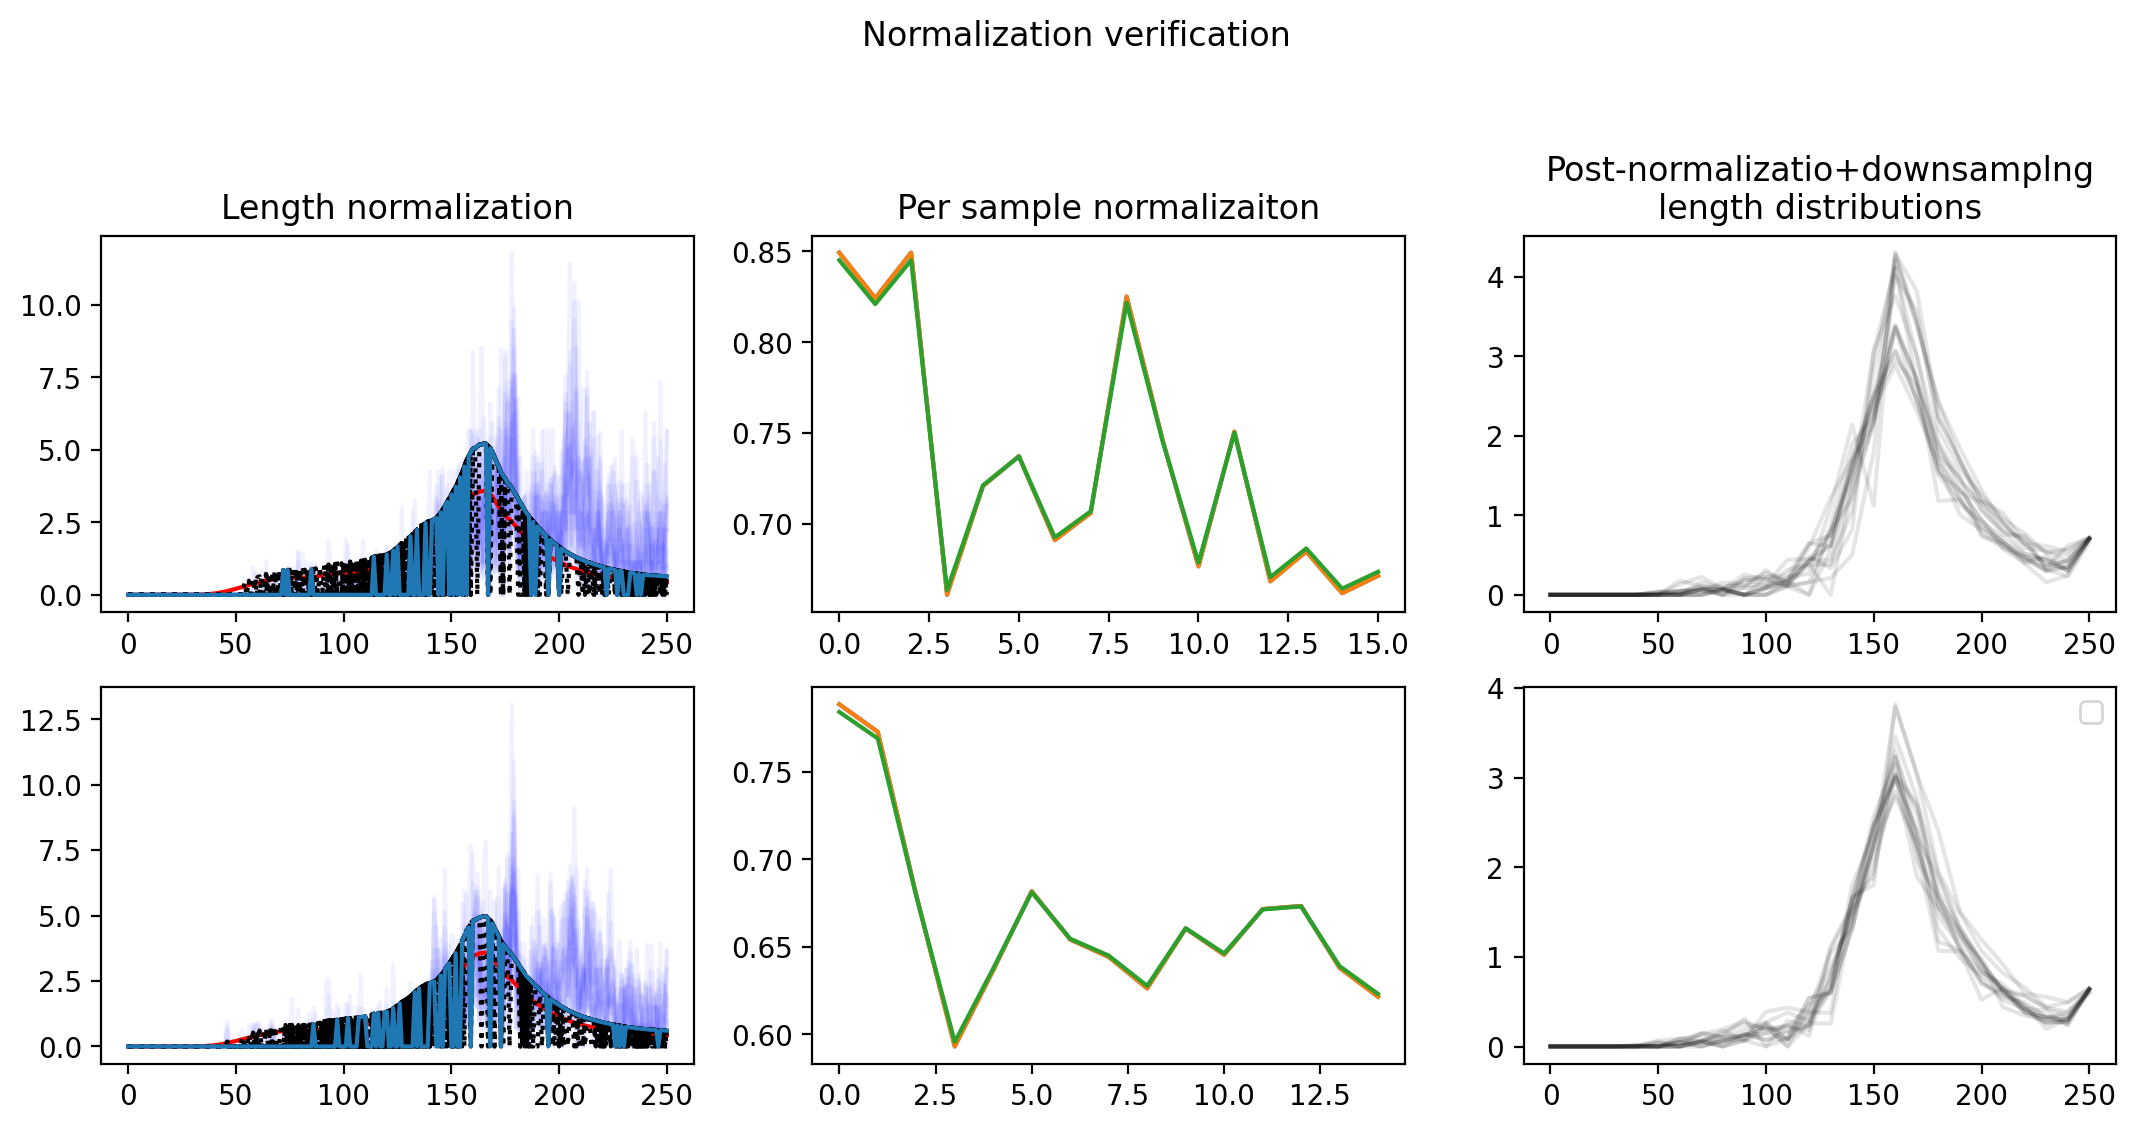

In [386]:
fig = combined_model.plot_normalization_sanity_check()

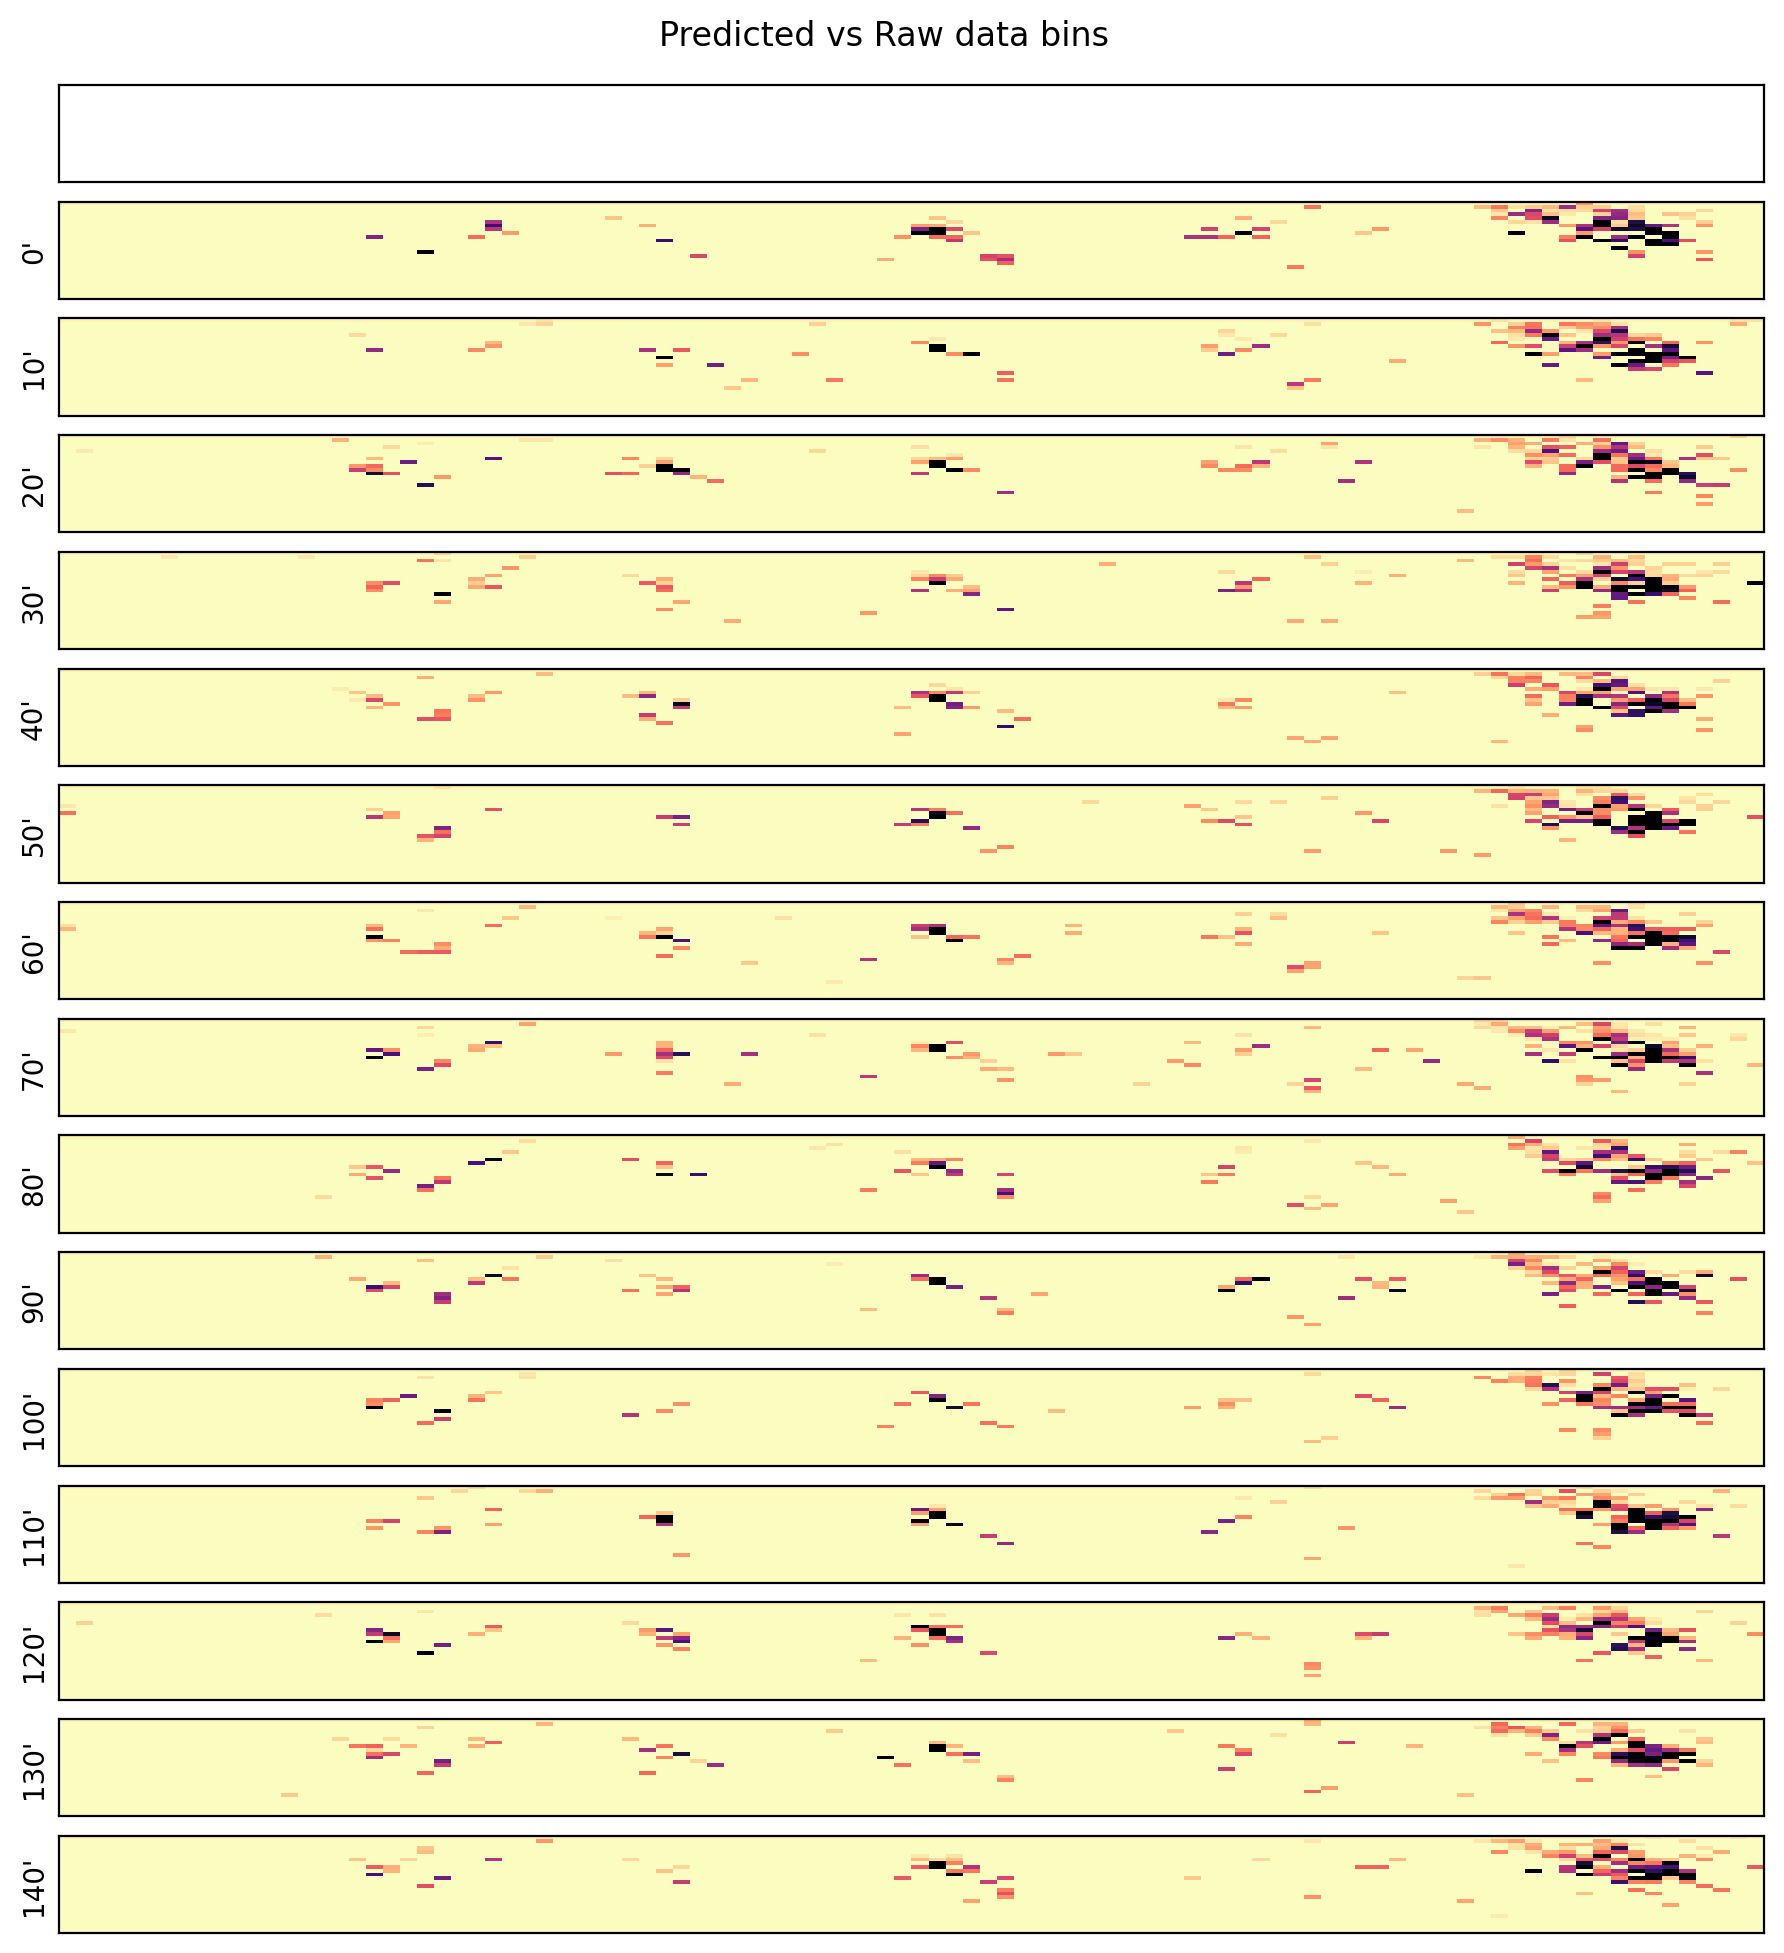

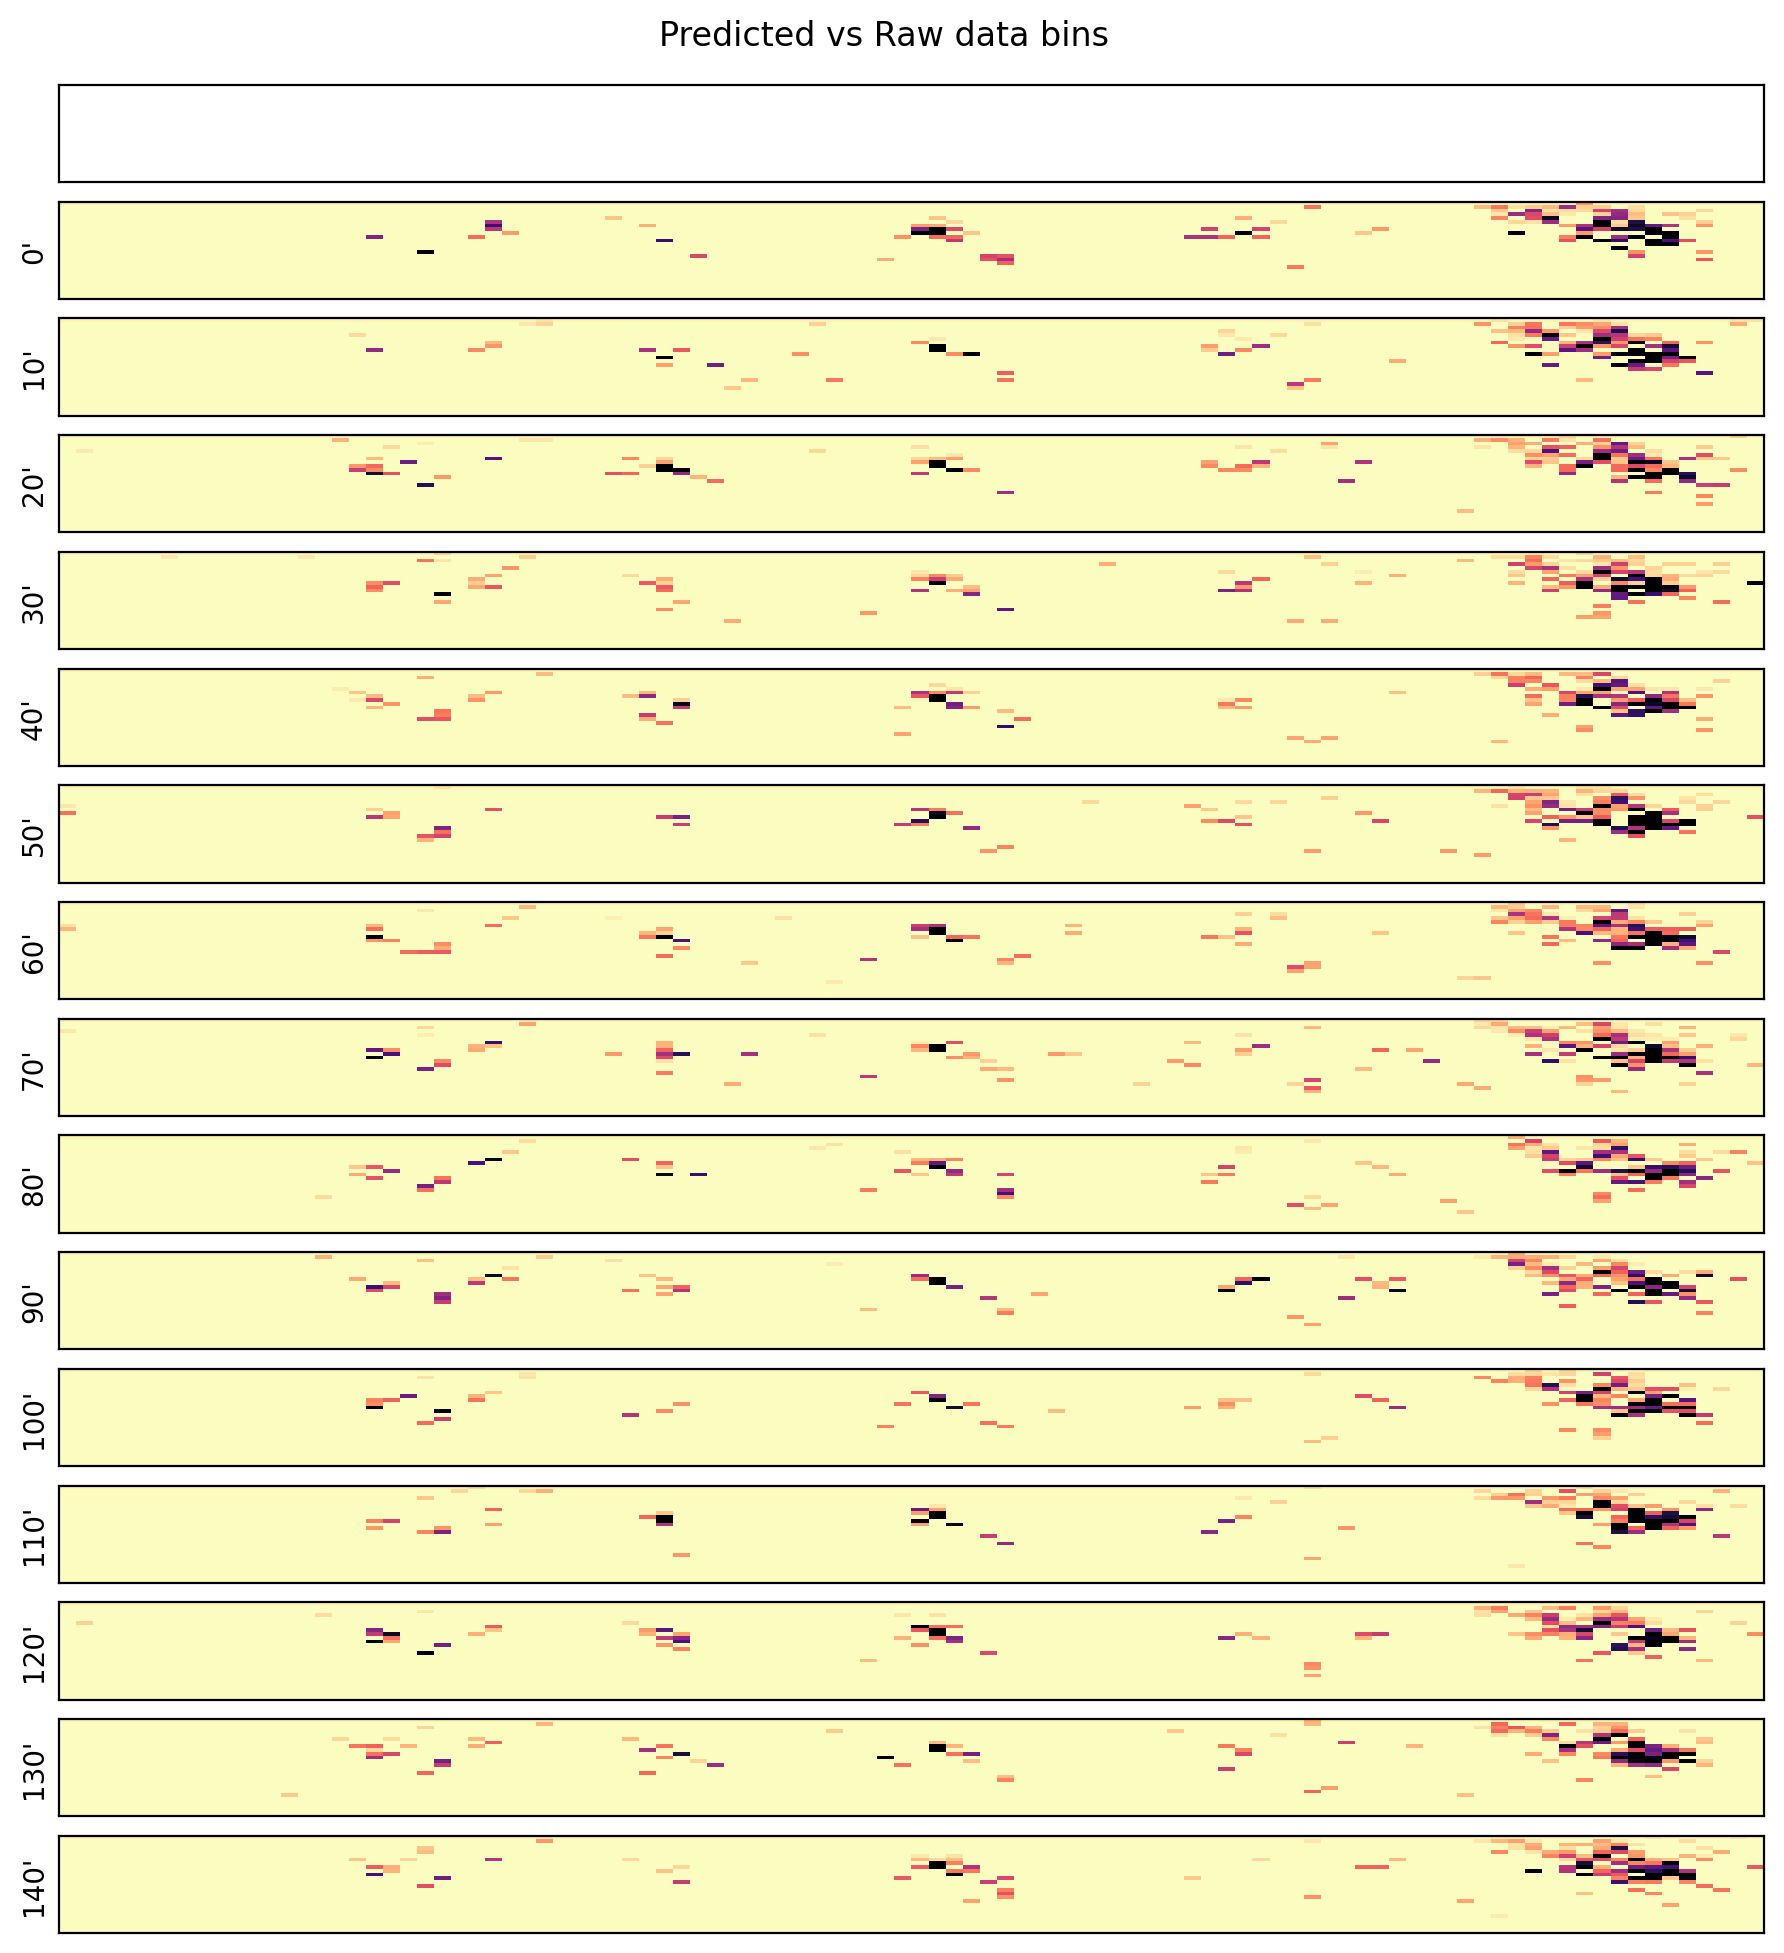

In [387]:
combined_model.chrom2_model.plot_raw_data(figsize=(11, 11))

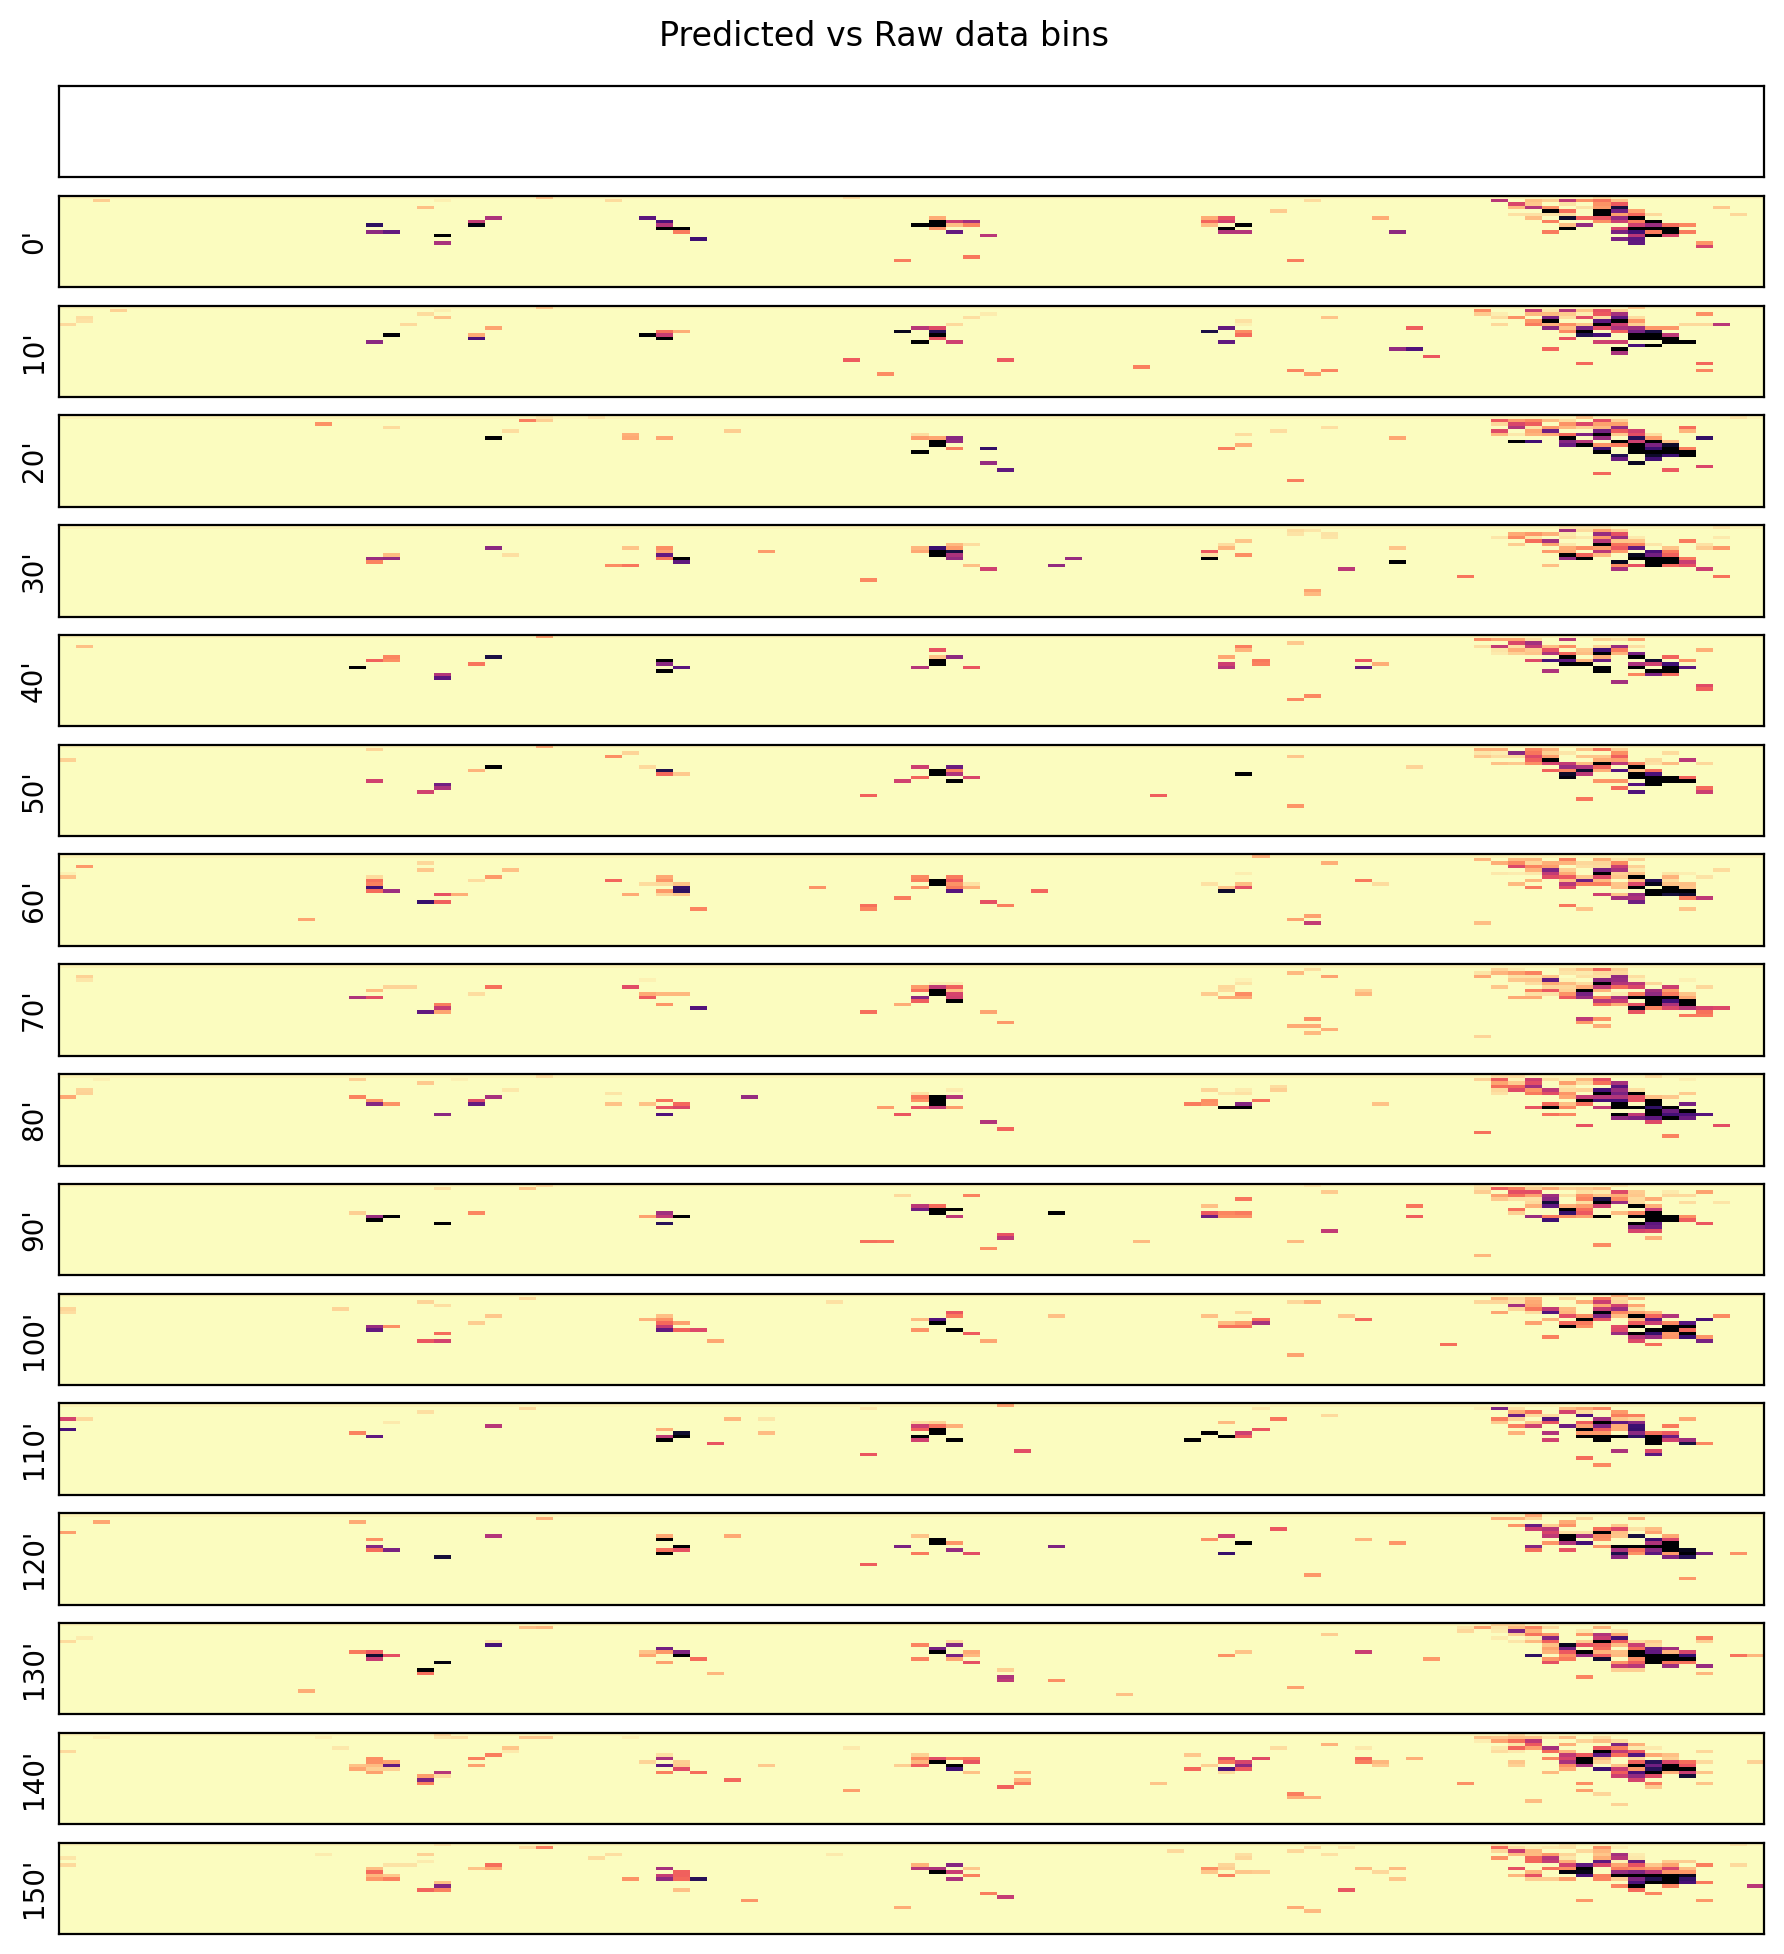

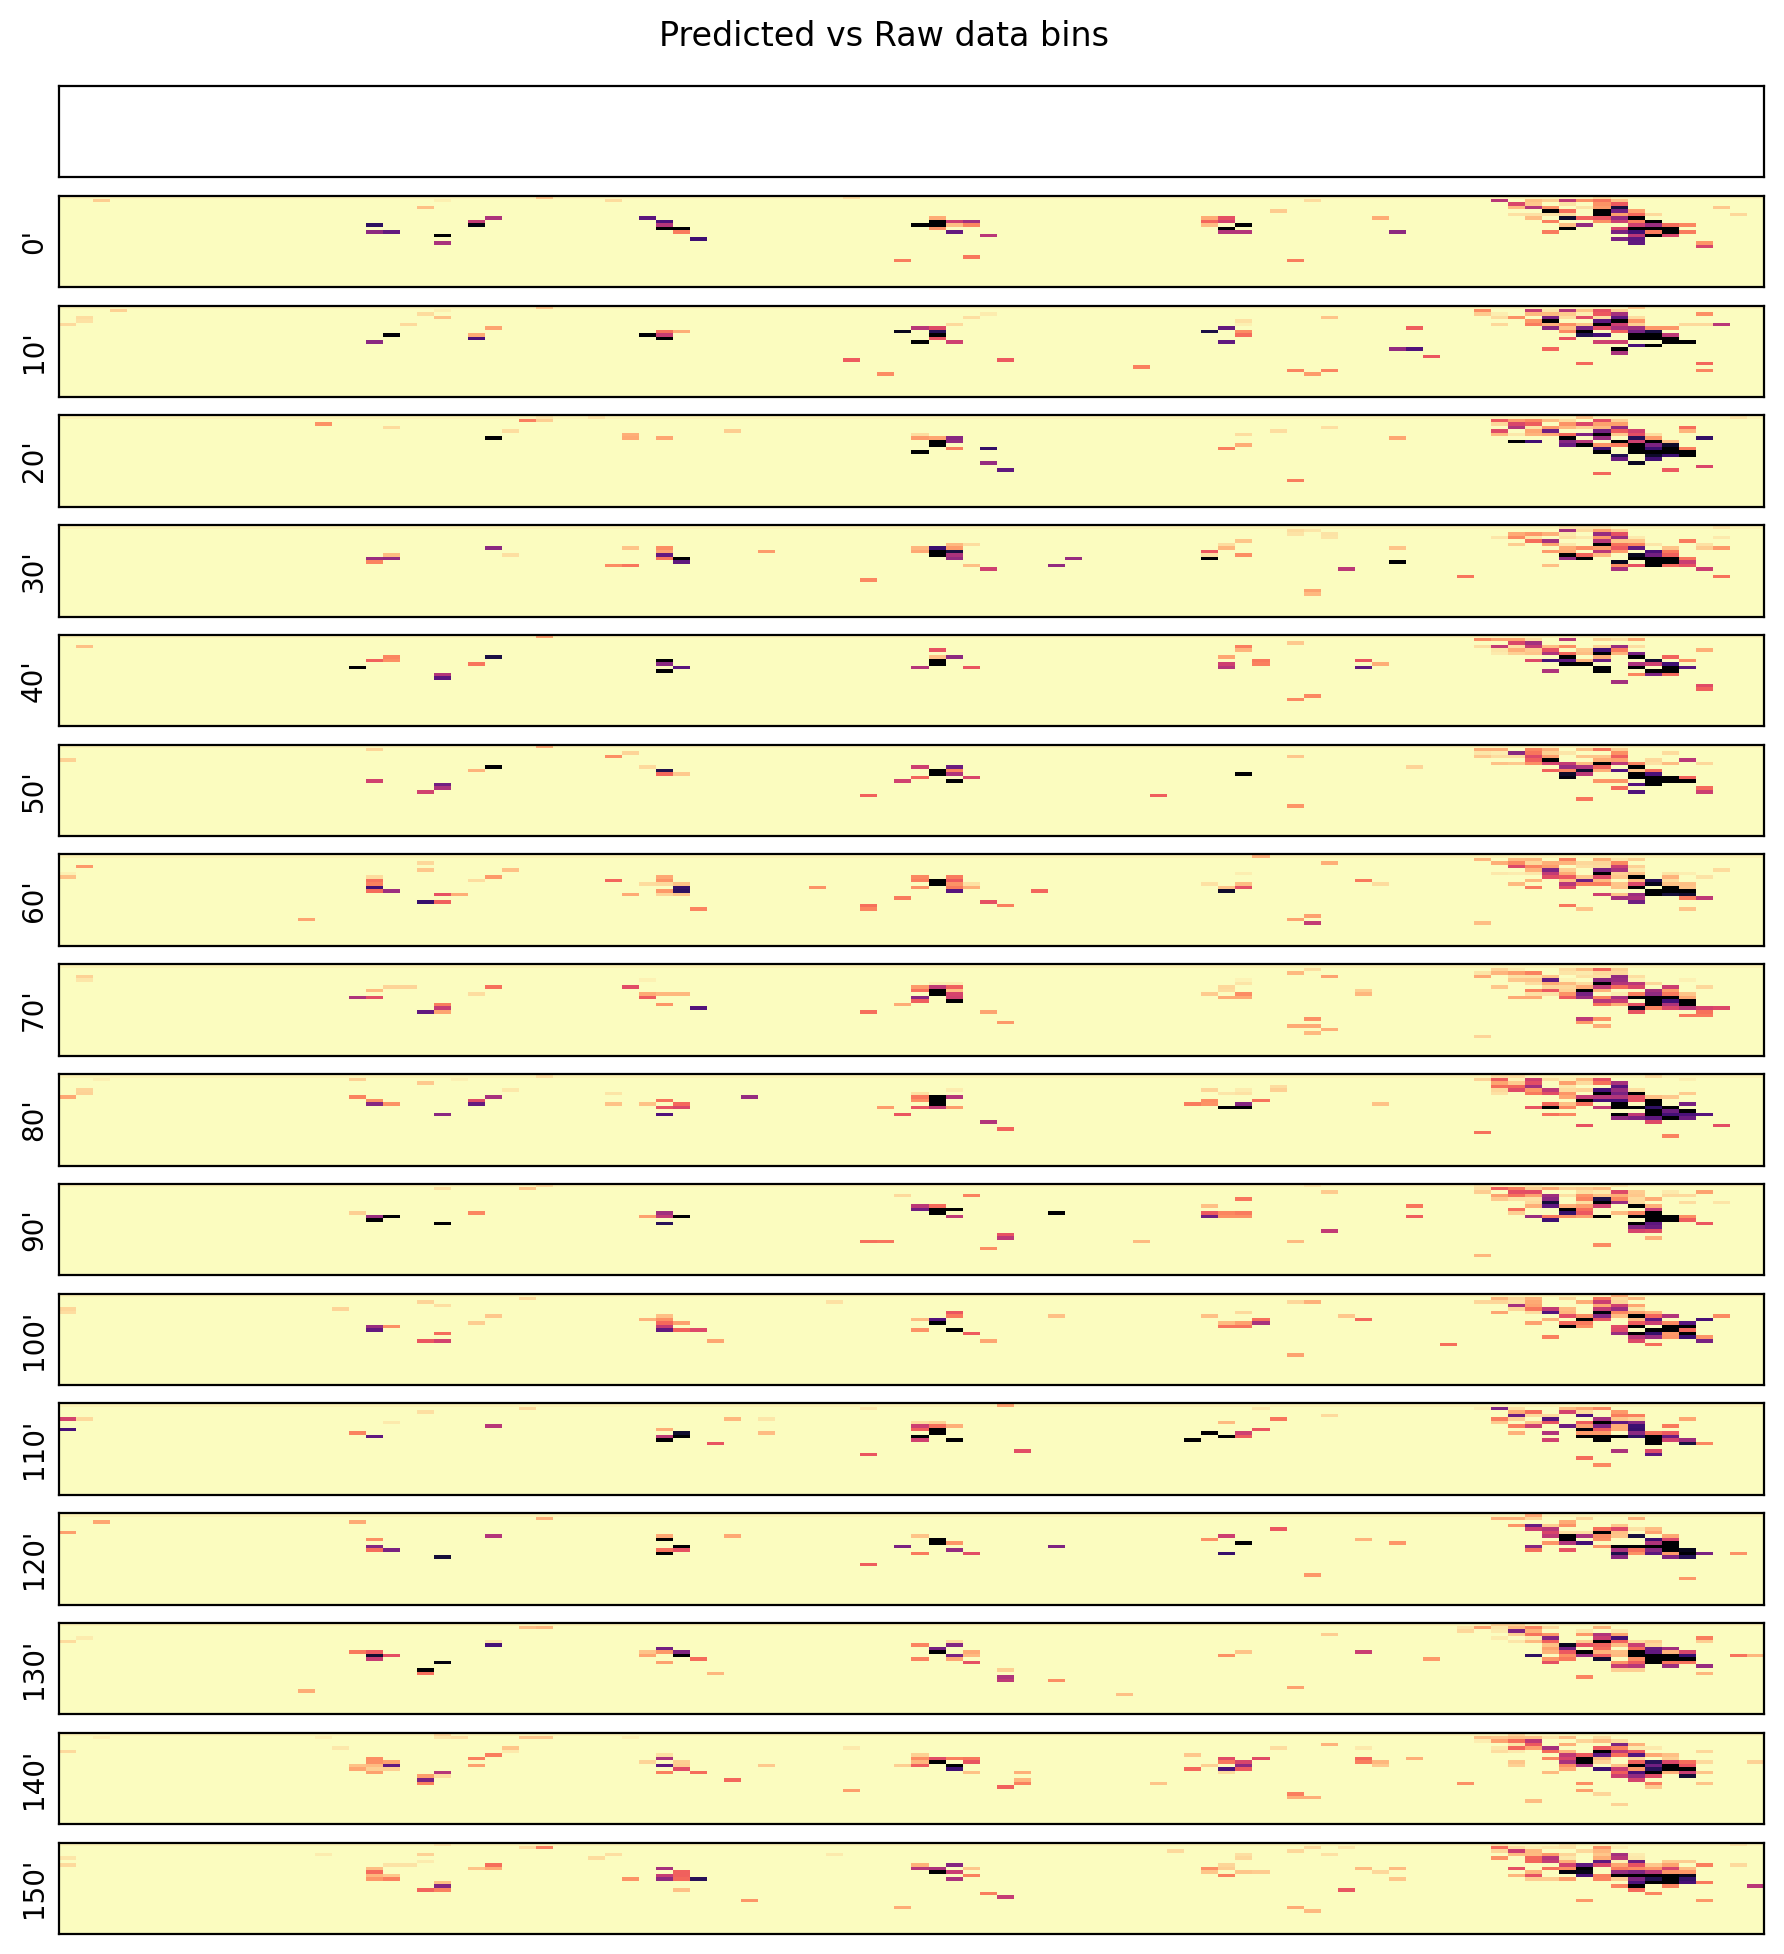

In [388]:
combined_model.chrom1_model.plot_raw_data(figsize=(11, 11))

In [389]:
combined_model.setup_deconv_model()

todo: Loading copy correction N, Fr, B, testing with prototype replication data
Loading single replication profile, 3/1/25
Trial N, need to use combined N curve


In [390]:
combined_model.deconvolve(gamma=0.01, kappa=0, verbose=True)

0/2600 - 00:00:00.000
500/2600 - 00:00:01.287
1000/2600 - 00:00:10.684
1500/2600 - 00:00:30.383
2000/2600 - 00:01:03.734
2500/2600 - 00:01:31.404
Completed - 00:01:46.542


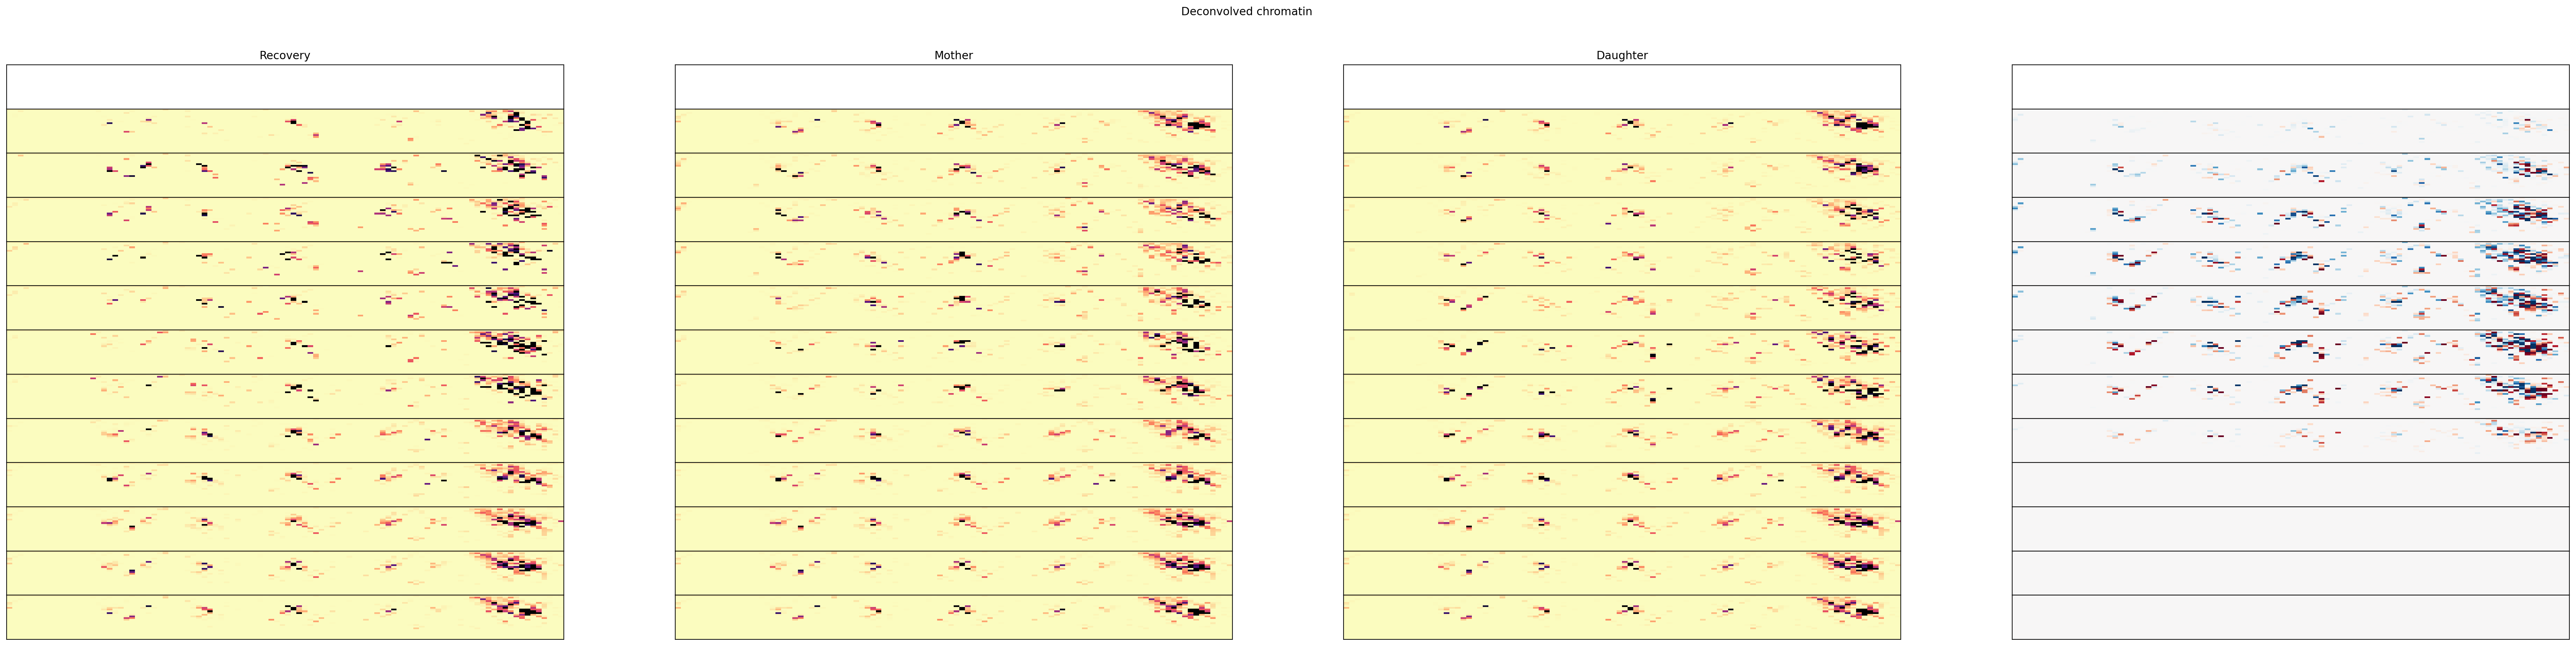

In [391]:
combined_model.plot_branches(figsize=(50, 11))

In [540]:
from src.geneset import create_windows_to_deconvolve

window_set = create_windows_to_deconvolve(ro)

window_set_10kb.to_csv("datasets/computed_mnase/test_window_set_10kb.csv",
                 index=False)
window_set_10kb = window_set_10kb.reset_index(drop=True)
window_set_10kb

,start,group,chr,end,name
0,1018000,early_chr4,4,1028000,early_chr4
1,1348000,early_chr4,4,1358000,early_chr4
2,1150000,early_chr4,4,1160000,early_chr4
3,334000,early_chr4,4,344000,early_chr4
4,462000,early_chr4,4,472000,early_chr4
5,674000,late_chr4,4,684000,late_chr4
6,780000,late_chr4,4,790000,late_chr4
7,668000,late_chr4,4,678000,late_chr4
8,958000,late_chr4,4,968000,late_chr4
9,964000,late_chr4,4,974000,late_chr4


# Analysis of chromatin deconvolution

1. Start with sanity checks, show that we are able to load any of the deconvolution windows

In [408]:
output_directory = \
    'output/prototype_pipeline_subset/'
chromatin_deconvolution_directory = \
    f'{output_directory}/chromatin_deconvolution/'

def load_deconvolved_window(chrom, span, chromatin_deconvolution_directory):
    filepath = f'deconvolution_data/chr{chrom}/chr{chrom}_{span[0]}_{span[1]}_F.npy'
    deconv_F_path = f'{chromatin_deconvolution_directory}/{filepath}'
    F_data = np.load(deconv_F_path)
    return F_data


(149, 26000)

In [422]:
def load_combined_model_for_row(row):
    """"Load the deconvolution data from disk and place in combined model for
    analysis"""
    mnase_span = row.start, row.end
    chrom = row.chr

    loaded_F_data = load_deconvolved_window(chrom, mnase_span, 
        chromatin_deconvolution_directory)

    config1, config2 = load_config_from_replication_runs(
        f'{output_directory}/single_replication/', chrom=4)

    from src.combined_chromatin_model import CombinedChromatinModel
    combined_model = CombinedChromatinModel(config1=config1, config2=config2)
    combined_model.load_mnase_span(chrom, mnase_span)
    combined_model.setup_deconv_model()
    combined_model.solver.F = loaded_F_data
    
    return combined_model


In [450]:
# Streamline of combined model loading of deconvolution data from disk
# from the trial windows
window_set_10kb = pd.read_csv('datasets/computed_mnase/test_window_set_10kb.csv')
row = window_set_10kb[window_set_10kb['name'] == 'CLB3'] .iloc[0]
combined_model = load_combined_model_for_row(row)

Shifting mu0, gamma1, and gamma2, for alpha...
Loading chromosome reads: 4
Loading target length distribution:  datasets/computed_mnase/target_length_distribution.csv
Loading G data from combined replication run, 3/10/25
Refactor to use the output directory, of the replication deconvolution run
Normalizing to mean 1, to target length distribution, to target 10kb occupancy sums.
And downsampling from (16, 251, 9999) to (16, 26, 1000)
Loading chromosome reads: 4
Loading target length distribution:  datasets/computed_mnase/target_length_distribution.csv
Loading G data from combined replication run, 3/10/25
Refactor to use the output directory, of the replication deconvolution run
Normalizing to mean 1, to target length distribution, to target 10kb occupancy sums.
And downsampling from (15, 251, 9999) to (15, 26, 1000)
todo: Loading copy correction N, Fr, B, testing with prototype replication data
Loading single replication profile, 3/1/25
Trial N, need to use combined N curve


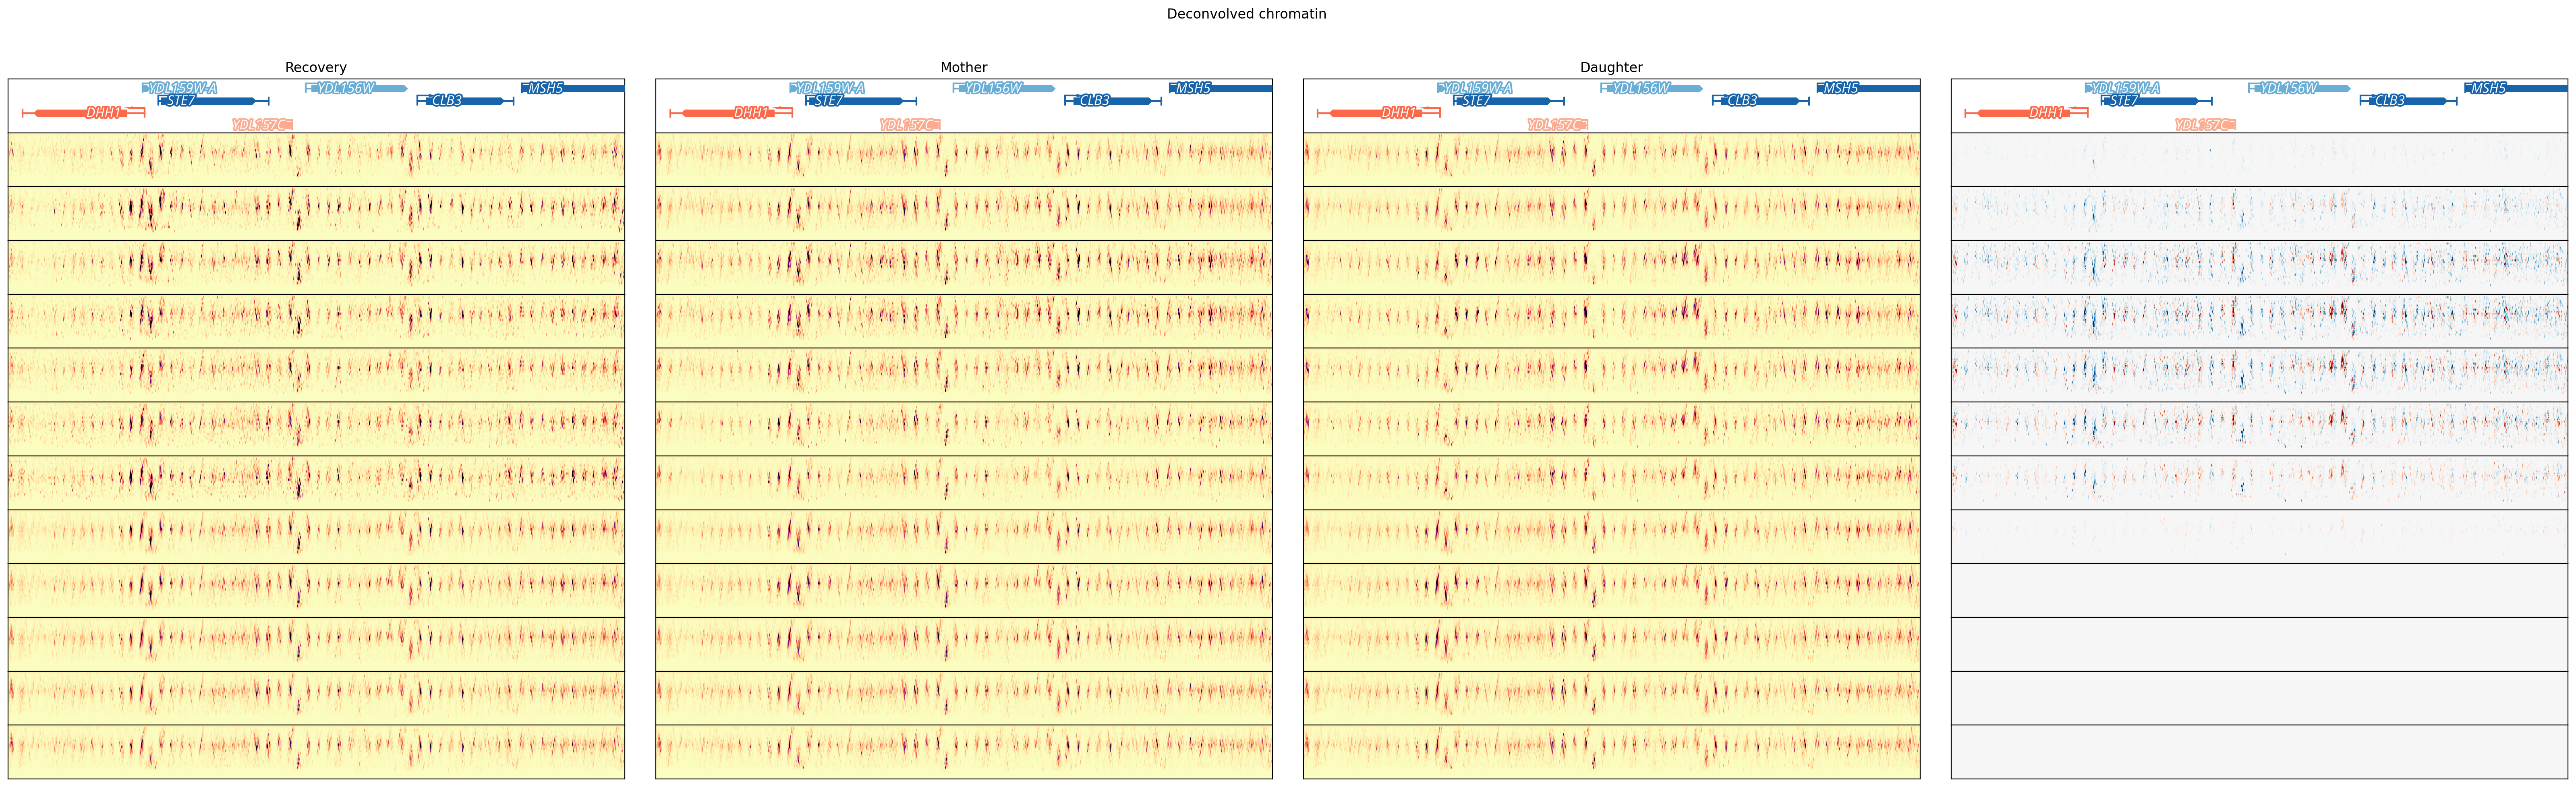

In [451]:
combined_model.plot_branches(figsize=(41, 11))